In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Sentiment_classification

/content/drive/MyDrive/Sentiment_classification


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
tf_df = pd.read_csv("/content/drive/MyDrive/Sentiment_classification/results/tfidf_results.csv")


In [14]:
tf_df = tf_df.rename(columns = {'nagram_range':'Ngram_range'})

In [29]:
tf_new = tf_df[tf_df["Accuracy"]>87.0]

In [30]:
tf_new

,Model,Max_features,Ngram_range,Accuracy,Time
0,Logistic Regression,5000.0,"(1, 1)",88.53,1.610341
1,Linear Support Vector Classifier,5000.0,"(1, 1)",87.97,3.810263
4,RNN(relu),5000.0,"(1, 1)",87.15,107.366059
5,Logistic Regression,5000.0,"(1, 2)",88.49,1.161445
6,Linear Support Vector Classifier,5000.0,"(1, 2)",88.32,1.930673
9,RNN(relu),5000.0,"(1, 2)",87.34,105.509916
10,Logistic Regression,5000.0,"(1, 3)",88.51,0.390856
11,Linear Support Vector Classifier,5000.0,"(1, 3)",88.22,1.347347
14,Logistic Regression,10000.0,"(1, 2)",89.19,1.353774
15,Linear Support Vector Classifier,10000.0,"(1, 2)",88.94,2.061418


In [31]:
#create a descriptive label for the Y-axis
tf_new['configuration'] = tf_new['Model'] + "(MF:" + tf_new["Max_features"].astype(str) + ",NG:" + tf_new["Ngram_range"]+")"

/tmp/ipykernel_3279/129813547.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tf_new['configuration'] = tf_new['Model'] + "(MF:" + tf_new["Max_features"].astype(str) + ",NG:" + tf_new["Ngram_range"]+")"


/tmp/ipykernel_3279/1241450145.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


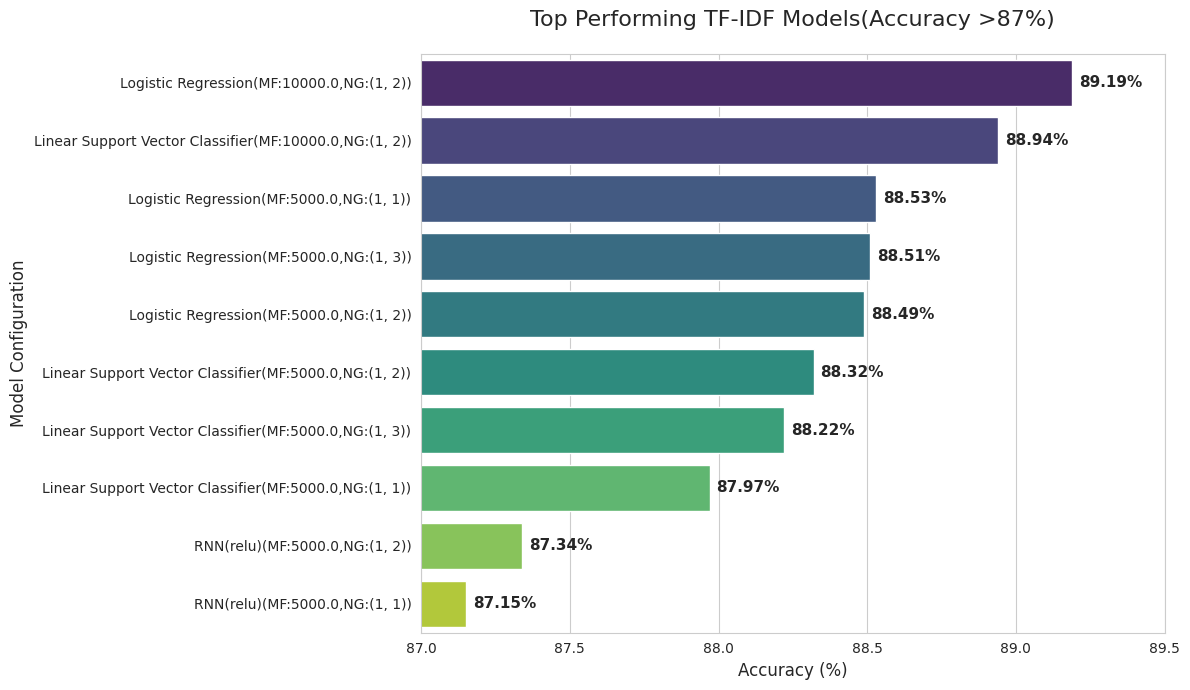

In [34]:

#sort accuracy for better visual flow
tf_new = tf_new.sort_values(by = "Accuracy", ascending = False)

#plotting
plt.figure(figsize = (12,7))
sns.set_style("whitegrid")

ax = sns.barplot(
    x = 'Accuracy',
    y = "configuration",
    data = tf_new,
    palette = 'viridis'
)

#Add text labels on the bars

for i in ax.containers:
  ax.bar_label(i, fmt = '%.2f%%', padding = 5, fontsize = 11,fontweight = 'bold')

#formatting the chart
plt.title('Top Performing TF-IDF Models(Accuracy >87%)', fontsize = 16, pad = 20)
plt.xlabel('Accuracy (%)', fontsize = 12)
plt.ylabel('Model Configuration', fontsize = 12)

#zoom in on the 88%-90% range to highlight the small differences
plt.xlim(87, 89.5)
plt.tight_layout()
plt.savefig('tfidf_top_results.png', dpi=300)
plt.show()


In [27]:
emb_df = pd.read_csv("/content/drive/MyDrive/Sentiment_classification/results/embedding_results.csv")

In [28]:
emb_df

,Model,vocab_size,embedding_size,sequence_length,hidden_size,num_layers,batch_size,num_epochs,Accuracy,Time
0,LSTM,10002,50,100,128,1,64,15,82.36,1483.085444
1,GRU,10002,50,100,128,1,64,15,83.19,1282.537741
2,BI-GRU,10002,50,100,128,1,64,15,82.15,2502.716264
3,CNN,10002,50,100,100_filters,1,64,15,83.05,975.712866
4,CNN,10002,50,150,100_filters,1,64,15,85.51,1328.375461
5,CNN,10002,50,200,100_filters,1,64,15,87.07,1706.744767
6,CNN (T4 GPU),10002,50,250,100_filters,1,64,15,88.37,1319.682696
7,CNN (T4 GPU),10002,100,100,100_filters,1,64,15,83.88,802.893360
8,CNN (T4 GPU),10002,100,200,100_filters,1,64,15,87.43,1722.728804
9,CNN (T4 GPU),10002,100,250,100_filters,1,64,15,88.83,2393.435264


In [35]:
emb_df_new = emb_df.iloc[3:10]

In [36]:
emb_df_new

,Model,vocab_size,embedding_size,sequence_length,hidden_size,num_layers,batch_size,num_epochs,Accuracy,Time
3,CNN,10002,50,100,100_filters,1,64,15,83.05,975.712866
4,CNN,10002,50,150,100_filters,1,64,15,85.51,1328.375461
5,CNN,10002,50,200,100_filters,1,64,15,87.07,1706.744767
6,CNN (T4 GPU),10002,50,250,100_filters,1,64,15,88.37,1319.682696
7,CNN (T4 GPU),10002,100,100,100_filters,1,64,15,83.88,802.893360
8,CNN (T4 GPU),10002,100,200,100_filters,1,64,15,87.43,1722.728804
9,CNN (T4 GPU),10002,100,250,100_filters,1,64,15,88.83,2393.435264


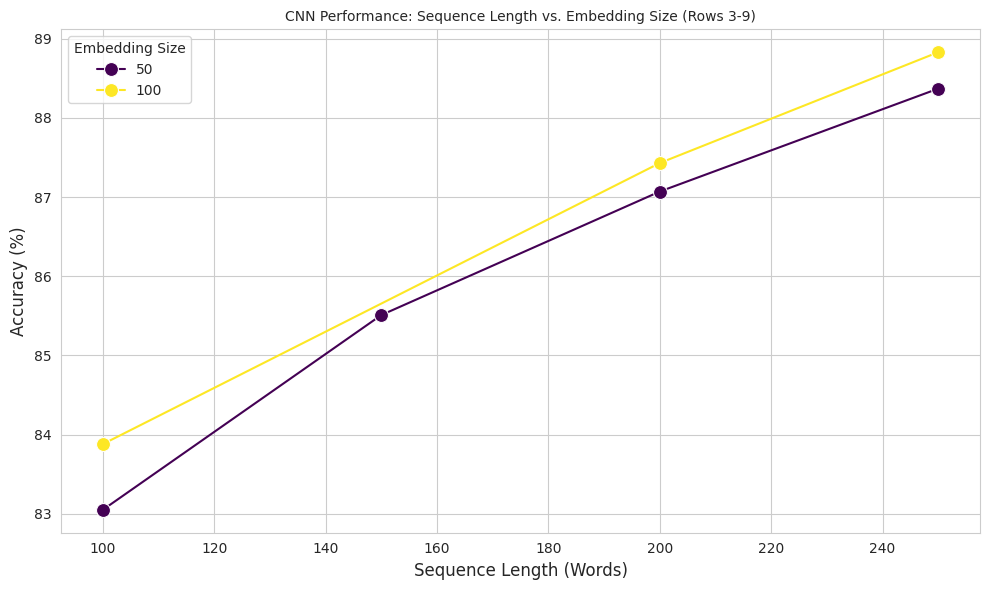

In [39]:
plt.figure(figsize = (10,6))
sns.set_style('whitegrid')

#line plot
sns.lineplot(data = emb_df_new, x = "sequence_length", y = 'Accuracy',
             hue = 'embedding_size', marker = 'o', palette = 'viridis', markersize = 10)
plt.title('CNN Performance: Sequence Length vs. Embedding Size (Rows 3-9)', fontsize = 10)
plt.xlabel('Sequence Length (Words)', fontsize = 12)
plt.ylabel('Accuracy (%)', fontsize = 12)
plt.legend(title = "Embedding Size")



plt.tight_layout()
plt.savefig('seq_vs_emb.png')
plt.show()

In [40]:
emb_df_vocab = emb_df.iloc[9:11]

In [41]:
emb_df_vocab

,Model,vocab_size,embedding_size,sequence_length,hidden_size,num_layers,batch_size,num_epochs,Accuracy,Time
9,CNN (T4 GPU),10002,100,250,100_filters,1,64,15,88.83,2393.435264
10,CNN (T4 GPU),15002,100,250,100_filters,1,64,15,89.07,2464.030855


/tmp/ipykernel_3279/2910890072.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = 'vocab_size', y = 'Accuracy',data = emb_df_vocab, palette = 'viridis')


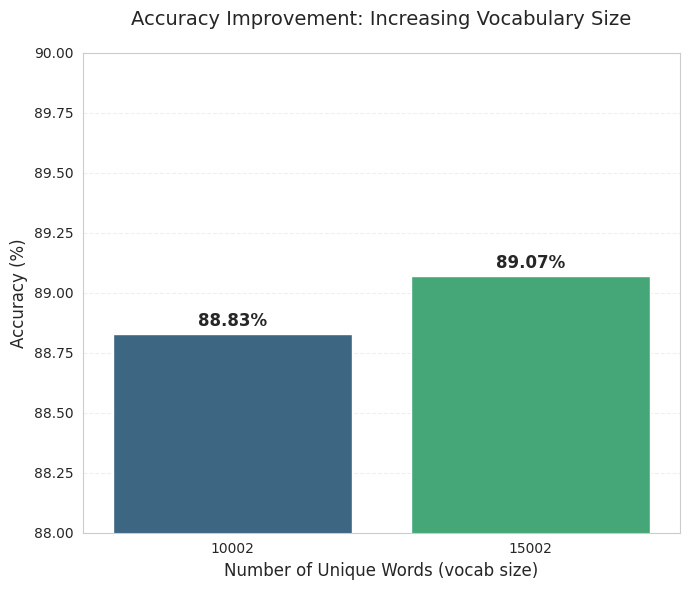

In [55]:
plt.figure(figsize = (7,6))
sns.set_style("whitegrid")

ax = sns.barplot(x = 'vocab_size', y = 'Accuracy',data = emb_df_vocab, palette = 'viridis')

for p in ax.patches:
  ax.annotate(f'{p.get_height():.2f}%',
   (p.get_x() + p.get_width()/2.,p.get_height()),
    ha = 'center', va = 'center',xytext = (0,9), textcoords ='offset points',fontsize = 12, fontweight = 'bold')


plt.ylim(88, 90)
plt.title('Accuracy Improvement: Increasing Vocabulary Size', fontsize = 14, pad = 20)
plt.ylabel('Accuracy (%)', fontsize = 12)
plt.xlabel('Number of Unique Words (vocab size)', fontsize = 12)

plt.grid(axis ='y', linestyle = '--', alpha = 0.3)
plt.tight_layout()
plt.savefig('vocab_vs_acc.png')
plt.show()

In [58]:
tf_new

,Model,Max_features,Ngram_range,Accuracy,Time,configuration
14,Logistic Regression,10000.0,"(1, 2)",89.19,1.353774,"Logistic Regression(MF:10000.0,NG:(1, 2))"
15,Linear Support Vector Classifier,10000.0,"(1, 2)",88.94,2.061418,"Linear Support Vector Classifier(MF:10000.0,NG..."
0,Logistic Regression,5000.0,"(1, 1)",88.53,1.610341,"Logistic Regression(MF:5000.0,NG:(1, 1))"
10,Logistic Regression,5000.0,"(1, 3)",88.51,0.390856,"Logistic Regression(MF:5000.0,NG:(1, 3))"
5,Logistic Regression,5000.0,"(1, 2)",88.49,1.161445,"Logistic Regression(MF:5000.0,NG:(1, 2))"
6,Linear Support Vector Classifier,5000.0,"(1, 2)",88.32,1.930673,"Linear Support Vector Classifier(MF:5000.0,NG:..."
11,Linear Support Vector Classifier,5000.0,"(1, 3)",88.22,1.347347,"Linear Support Vector Classifier(MF:5000.0,NG:..."
1,Linear Support Vector Classifier,5000.0,"(1, 1)",87.97,3.810263,"Linear Support Vector Classifier(MF:5000.0,NG:..."
9,RNN(relu),5000.0,"(1, 2)",87.34,105.509916,"RNN(relu)(MF:5000.0,NG:(1, 2))"
4,RNN(relu),5000.0,"(1, 1)",87.15,107.366059,"RNN(relu)(MF:5000.0,NG:(1, 1))"


In [61]:
final_df = tf_new.loc[tf_new['Accuracy']>89,['configuration', 'Accuracy','Time']]

In [74]:
emb_df['configuration'] = emb_df['Model'] + "(vocab_size: "+emb_df['vocab_size'].astype(str) +", emb: "+ emb_df['embedding_size'].astype(str)+", seq: "+emb_df["sequence_length"].astype(str)+")"

In [75]:
final_em_df = emb_df.loc[emb_df["Accuracy"]>89,['configuration', 'Accuracy', 'Time']]

In [76]:
final_em_df

,configuration,Accuracy,Time
10,"CNN (T4 GPU)(vocab_size: 15002, emb: 100, seq:...",89.07,2464.030855


In [77]:
final_pre_emb = pd.read_csv("/content/drive/MyDrive/Sentiment_classification/results/pretrained_embedding_results.csv")

In [78]:
final_pre_emb

,Model,vocab_size,embedding_size,sequence_length,hidden_size,num_filters,num_layers,batch_size,num_epochs,Accuracy,Time
0,CNN(Word2Vec),20002,100,250,-,100,1,64,15,89.600000,2836.796211
1,CNN(glove),20002,100,250,-,100,1,64,15,89.126667,2870.457033


In [79]:
final_pre_emb['configuration'] = final_pre_emb['Model'] + "(vocab_size: "+final_pre_emb['vocab_size'].astype(str) +", emb: "+ final_pre_emb['embedding_size'].astype(str)+", seq: "+final_pre_emb["sequence_length"].astype(str)+")"

In [80]:
final_pre_emb_df = final_pre_emb.loc[final_pre_emb['Accuracy']>89,['configuration','Accuracy','Time']]

In [82]:
final_pre_emb_df

,configuration,Accuracy,Time
0,"CNN(Word2Vec)(vocab_size: 20002, emb: 100, seq...",89.600000,2836.796211
1,"CNN(glove)(vocab_size: 20002, emb: 100, seq: 250)",89.126667,2870.457033


In [85]:
final_df = pd.concat([final_df,final_em_df,final_pre_emb_df], ignore_index = True)

In [86]:
final_df

,configuration,Accuracy,Time
0,"Logistic Regression(MF:10000.0,NG:(1, 2))",89.190000,1.353774
1,"CNN (T4 GPU)(vocab_size: 15002, emb: 100, seq:...",89.070000,2464.030855
2,"CNN(Word2Vec)(vocab_size: 20002, emb: 100, seq...",89.600000,2836.796211
3,"CNN(glove)(vocab_size: 20002, emb: 100, seq: 250)",89.126667,2870.457033


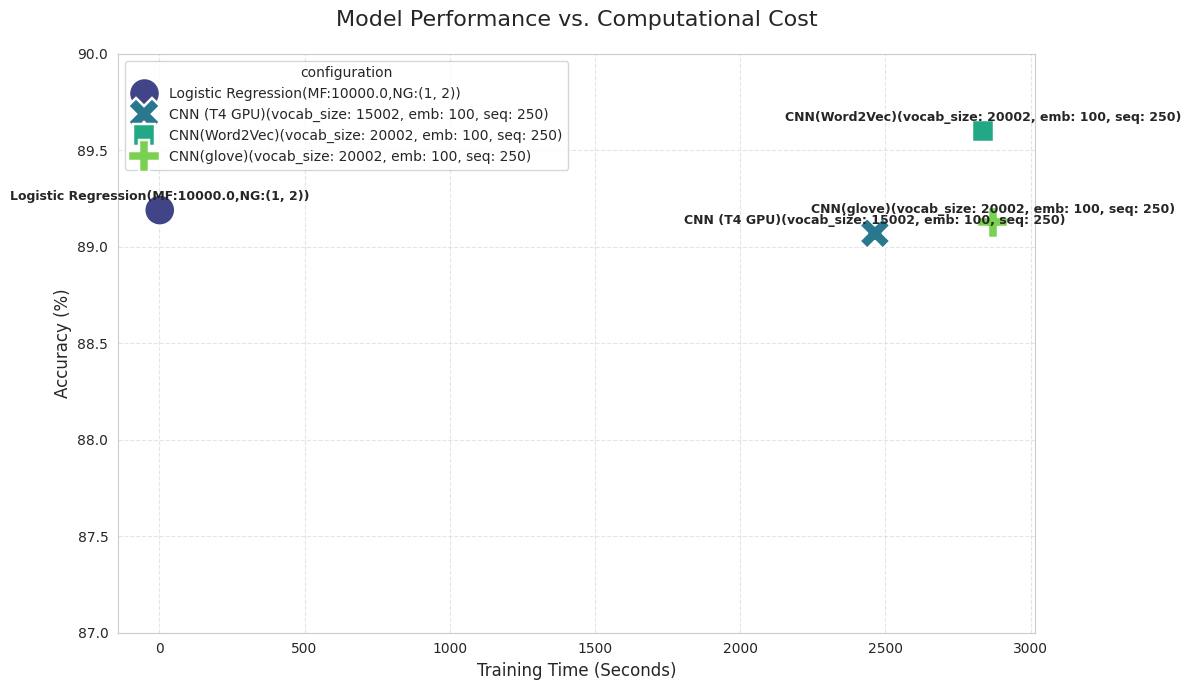

In [92]:
plt.figure(figsize = (12,7))
sns.set_style("whitegrid")

ax = sns.scatterplot(data = final_df,
                     x = 'Time',
                     y = 'Accuracy',
                     hue = 'configuration',
                     style = 'configuration',
                     s = 500,
                     palette = 'viridis')
# Label each point with the Configuration name
for i in range(final_df.shape[0]):
    plt.text(
        final_df.Time[i],
        final_df.Accuracy[i] + 0.05,
        final_df.configuration[i],
        fontsize=9,
        ha='center',
        fontweight='bold'
    )

plt.title('Model Performance vs. Computational Cost', fontsize=16, pad=20)
plt.xlabel('Training Time (Seconds)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(87, 90) # Zoom in on the high-performance area
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.savefig('final_models_comapar.png')
plt.show()

